In [ ]:
# Import pakages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from optbinning import OptimalBinning
import matplotlib as mpl
#import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Classification modeling pakages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import metrics, classification_report, roc_auc_score
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score
import lightgbm as lgbm
from lightgbm import LGBMClassifier

# NLP pakages
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

## 4. Churn risk among repeat customers
### Among customers who have made at least one repeat purchase, which characteristics are associated with a higher risk of churn?


In [2]:
# Import data
multi_day_df = pd.read_csv("multi_day_df.csv")

# Make the label
multi_day_df['Churn'] = (multi_day_df['Days_Since_Last_Purchase'] > 180).astype(int)

In [3]:
multi_day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102438 entries, 0 to 102437
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   customer_id                     102438 non-null  object 
 1   Days_Since_Last_Purchase        102438 non-null  int64  
 2   Total_Transactions              102438 non-null  int64  
 3   Total_Products_Purchased        102438 non-null  int64  
 4   Total_Spend                     102438 non-null  float64
 5   Average_Transaction_Value       102438 non-null  float64
 6   Unique_Products_Purchased       102438 non-null  int64  
 7   Average_Days_Between_Purchases  102438 non-null  float64
 8   Day_Of_Week                     102438 non-null  int64  
 9   Preferred_Sales_Channel         102438 non-null  int64  
 10  Monthly_Spending_Mean           102438 non-null  float64
 11  Monthly_Spending_Std            102438 non-null  float64
 12  Spending_Trend  

(array([21822., 21353., 13331., 10534., 10686.,  8802.,  8450.,  4255.,
         2243.,   962.]),
 array([  0. ,  73.1, 146.2, 219.3, 292.4, 365.5, 438.6, 511.7, 584.8,
        657.9, 731. ]),
 <BarContainer object of 10 artists>)

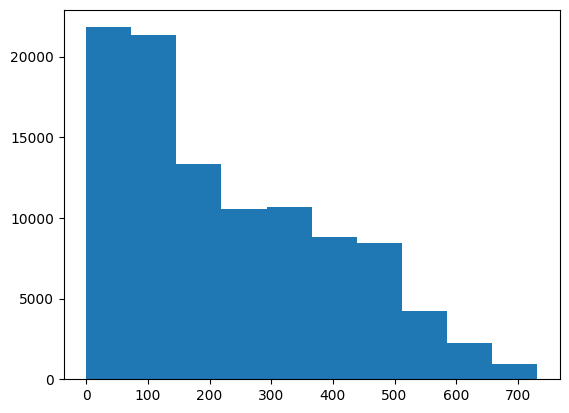

In [4]:
plt.hist(multi_day_df.Days_Since_Last_Purchase)

In [ ]:
# Check the target distribution
multi_day_df.Churn.value_counts()

Churn
1    52215
0    50223
Name: count, dtype: int64

In [ ]:
# Checking IV values 
# IV (Information Value) measures how well a variable distinguishes between events and non-events (e.g., churn vs. non-churn)
numerical_list = ['Total_Transactions', 'Total_Products_Purchased', 'Total_Spend', 'Average_Transaction_Value', \
                  'Unique_Products_Purchased',  'Average_Days_Between_Purchases', 'Monthly_Spending_Mean',
                  'Monthly_Spending_Std', 'Spending_Trend', 'age']
iv_df = []

for i in numerical_list :
  variable = i
  x = multi_day_df[variable].values
  y = multi_day_df.Churn
  optb = OptimalBinning(name=variable, dtype="numerical", max_n_prebins=3)
  optb.fit(x, y)

  binning_table = optb.binning_table
  v1 = binning_table.build()

  loop_df = pd.DataFrame({'val' : variable,
                          'IV' : [v1.loc['Totals','IV']]})
  iv_df.append(loop_df)

iv_df = pd.concat(iv_df).reset_index(drop=True)
iv_df.sort_values(by=['IV'], ascending = False)

# Average_Days_Between_Purchases : Information leakage 
# Binning try : Total_Transactions, Unique_Products_Purchased, Total_Products_Purchased 

,val,IV
5,Average_Days_Between_Purchases,0.516252
0,Total_Transactions,0.190795
4,Unique_Products_Purchased,0.156085
1,Total_Products_Purchased,0.155804
2,Total_Spend,0.064166
7,Monthly_Spending_Std,0.028128
8,Spending_Trend,0.024218
3,Average_Transaction_Value,0.011510
6,Monthly_Spending_Mean,0.009834
9,age,0.004743


In [7]:
# checking binning 
def plot_binning_event_rate(variable) : 
    x = multi_day_df[variable].values
    y = multi_day_df.Churn

    optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", max_n_prebins=3)
    optb.fit(x, y)

    binning_table = optb.binning_table
    v1 = binning_table.build()

    display(v1)

    mpl.rcParams.update({
    "figure.figsize": (6, 3),
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.labelsize": 5,
    "axes.titlesize": 10,
    })
    binning_table.plot(metric="event_rate")
    plt.show()

    return optb 

- Numerical variable

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 2.50)",62966,0.614674,26181,36785,0.584204,-0.301159,0.055171,0.006870
1,"[2.50, 4.50)",31344,0.305980,17836,13508,0.430960,0.316834,0.030554,0.003803
2,"[4.50, inf)",8128,0.079346,6206,1922,0.236467,1.211047,0.105070,0.012386
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,102438,1.000000,50223,52215,0.509723,,0.190795,0.023060


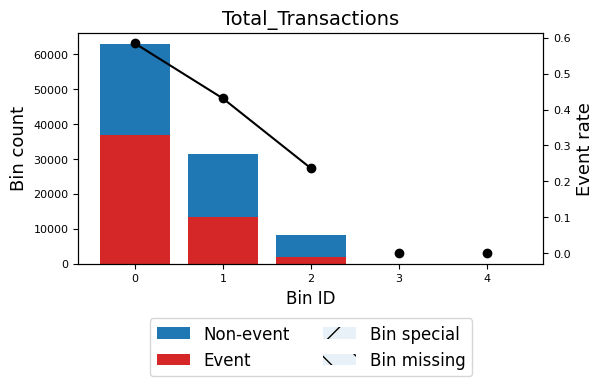

,name,'Total_Transactions'
,dtype,'numerical'
,prebinning_method,'cart'
,solver,'cp'
,divergence,'iv'
,max_n_prebins,3
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None


In [8]:
# numeric one col plotting 

# If the WoE signs change in a single direction, the magnitude order is intuitive, 
# and the event rate interpretation is consistent, then the variable is worth considering for binning.
optb  = plot_binning_event_rate('Total_Transactions')
optb

In [ ]:
# x_transform_bins = optb.transform(merged_df['Total_Transactions'].values,metric="woe")

# df_bin = multi_day_df[['Churn']].copy()
# df_bin['bin'] = x_transform_bins

# multi_day_df['Total_Transactions'] = df_bin['bin']
# multi_day_df.head(1)

####

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 2.50)",57667,0.562945,24005,33662,0.583731,-0.299211,0.049882,0.006212
1,"[2.50, 3.50)",24207,0.236309,12512,11695,0.483125,0.106424,0.002677,0.000334
2,"[3.50, inf)",20564,0.200746,13706,6858,0.333495,0.731315,0.103526,0.012660
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,102438,1.000000,50223,52215,0.509723,,0.156085,0.019206


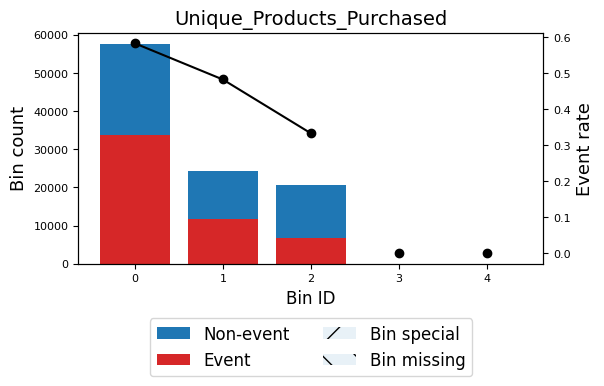

,name,'Unique_Products_Purchased'
,dtype,'numerical'
,prebinning_method,'cart'
,solver,'cp'
,divergence,'iv'
,max_n_prebins,3
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None


In [9]:
optb = plot_binning_event_rate('Unique_Products_Purchased')
optb

In [ ]:
# x_transform_bins = optb.transform(multi_day_df['Unique_Products_Purchased'].values,metric="woe")

# df_bin = multi_day_df[['Churn']].copy()
# df_bin['bin'] = x_transform_bins

# multi_day_df['Unique_Products_Purchased'] = df_bin['bin']
# multi_day_df.head(1)

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 2.50)",57503,0.561344,23937,33566,0.583726,-0.299192,0.049734,0.006194
1,"[2.50, 3.50)",24278,0.237002,12525,11753,0.484101,0.102515,0.002491,0.000311
2,"[3.50, inf)",20657,0.201654,13761,6896,0.333834,0.729794,0.103579,0.012667
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,102438,1.000000,50223,52215,0.509723,,0.155804,0.019172


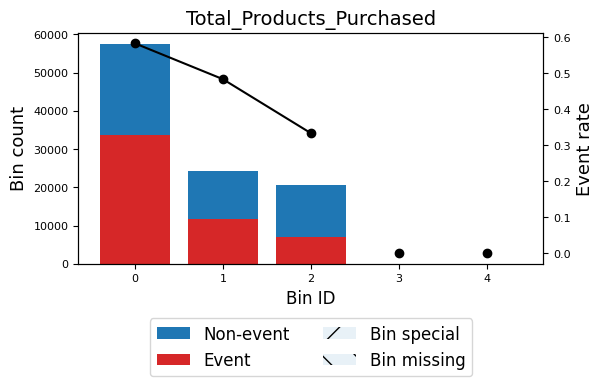

,name,'Total_Products_Purchased'
,dtype,'numerical'
,prebinning_method,'cart'
,solver,'cp'
,divergence,'iv'
,max_n_prebins,3
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None


In [10]:
# Not that strong, but still valuable (WoE, Event rate )
optb = plot_binning_event_rate('Total_Products_Purchased')
optb

In [293]:
# x_transform_bins = optb.transform(merged_df['Total_Products_Purchased'].values,metric="woe")

# df_bin = merged_df[['Churn']].copy()
# df_bin['bin'] = x_transform_bins

# merged_df['Total_Products_Purchased'] = df_bin['bin']
# merged_df.head(1)

In [ ]:
# Category 
categorical_list = ['Day_Of_Week', 'club_member_status', 'fashion_news_frequency']

iv_df = []

for i in categorical_list :
  variable = i
  x = multi_day_df[variable].values
  y = multi_day_df.Churn
  # max_n_prebins
  optb = OptimalBinning(name=variable, dtype="categorical", solver="cp")
  optb.fit(x, y)
  multi_day_df[variable] = optb.transform(multi_day_df[variable], metric="bins")

list_of_df = []
for i in categorical_list :
 loof_df = pd.DataFrame({'val' : [i],
              'nunique': multi_day_df[i].nunique()})
 list_of_df.append(loof_df)
 
df_merge  = pd.concat(list_of_df).reset_index(drop=True)
df_merge.sort_values(by=['nunique'], ascending = False)

df_merge

,val,nunique
0,Day_Of_Week,6
1,club_member_status,1
2,fashion_news_frequency,2


In [ ]:
# Since the binning result collapses into a single bin, club_member_status column is dropped. 
multi_day_df.drop(columns = ['club_member_status'], inplace = True)

In [13]:
eda_df = multi_day_df.groupby('fashion_news_frequency')['Churn'].agg(cnt =('count'), t_cnt=('sum')).reset_index()
eda_df['t_ratio'] = eda_df['t_cnt'] / eda_df['cnt']
eda_df

,fashion_news_frequency,cnt,t_cnt,t_ratio
0,['NONE' 'UNKNOWN' 'Monthly'],56414,29453,0.522087
1,['Regularly'],46024,22762,0.494568


-  model selection - Logistc regression, Random forest, LightGBM

- Rogistic regression

In [ ]:
# Split the data
X = multi_day_df.drop(['customer_id', 'Average_Days_Between_Purchases', 'Days_Since_Last_Purchase', 'Churn'], axis=1)
Y = multi_day_df['Churn']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=1234)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(71706, 12)
(71706,)
(30732, 12)
(30732,)


In [ ]:
# For Logistc Regression - Onehotencoder
categorical_list = ['Day_Of_Week', 'fashion_news_frequency']
for col in categorical_list :
  encoder = OneHotEncoder()
  encoder.fit(x_train[[col]])
  onehot_train = pd.DataFrame(encoder.transform(x_train[[col]]).toarray(), columns = encoder.get_feature_names_out(), index=x_train.index)
  onehot_test = pd.DataFrame(encoder.transform(x_test[[col]]).toarray(), columns = encoder.get_feature_names_out(), index=x_test.index)
  # drop exist columns
  x_train = pd.concat([x_train,onehot_train], axis = 1).drop(columns = [col])
  x_test = pd.concat([x_test,onehot_test], axis = 1).drop(columns = [col])

In [ ]:
# For Logistic Regression - standardization 
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

In [ ]:
# Model Training

LR = LogisticRegression()
LR.fit(x_train_sc, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
y_pred_train = LR.predict(x_train_sc)
y_pred_test = LR.predict(x_test_sc)

print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.63      0.43      0.51     35156
           1       0.58      0.76      0.66     36550

    accuracy                           0.60     71706
   macro avg       0.61      0.59      0.59     71706
weighted avg       0.61      0.60      0.59     71706

              precision    recall  f1-score   support

           0       0.63      0.43      0.51     15067
           1       0.58      0.76      0.66     15665

    accuracy                           0.60     30732
   macro avg       0.61      0.59      0.59     30732
weighted avg       0.61      0.60      0.59     30732



In [ ]:
y_pred_train_proba = LR.predict_proba(x_train_sc)[:, 1] 
y_pred_test_proba = LR.predict_proba(x_test_sc)[:, 1] 

In [20]:
# Create an empty DataFrame to compare the performance of multiple models.
df_comparison = pd.DataFrame(columns = ['model', 'f1_train', 'f1_test', 'AUC_train', 'AUC_test', ])
df_comparison.columns = ['model', 'f1_train', 'f1_test', 'AUC_train', 'AUC_test']
df_comparison

,model,f1_train,f1_test,AUC_train,AUC_test


In [ ]:
lr_re = pd.DataFrame({ 'model' : ['LR'],
                      'f1_train' :  metrics.f1_score(y_train,y_pred_train),
                      'f1_test' : metrics.f1_score(y_test,y_pred_test),
                      'AUC_train' : roc_auc_score(y_train, y_pred_train_proba),
                      'AUC_test' : roc_auc_score(y_test, y_pred_test_proba)}
                    )

df_comparison = pd.concat([df_comparison, lr_re], ignore_index=True)

In [22]:
# LG outcomes : no overfitting, but usefull as baseline model → We need to use crossval etc tunining
df_comparison

,model,f1_train,f1_test,AUC_train,AUC_test
0,LR,0.657821,0.658277,0.627445,0.622554


- Tree based models

In [23]:
X = multi_day_df.drop(['customer_id', 'Average_Days_Between_Purchases', 'Days_Since_Last_Purchase', 'Churn'], axis=1)
Y = multi_day_df['Churn']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=1234)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(71706, 12)
(71706,)
(30732, 12)
(30732,)


In [ ]:
# Label encoding 
categorical_list = ['Day_Of_Week', 'fashion_news_frequency']
for col in categorical_list :
  encoder = LabelEncoder()
  encoder.fit(x_train[[col]])

  x_train[col] = encoder.transform(x_train[col]) 
  x_test[col] = encoder.transform(x_test[col]) 

- RandomForest

In [ ]:
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

# ▶ 예측
y_pred_train = rfc.predict(x_train)
y_pred_test = rfc.predict(x_test)

print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     35156
           1       0.98      0.99      0.99     36550

    accuracy                           0.99     71706
   macro avg       0.99      0.99      0.99     71706
weighted avg       0.99      0.99      0.99     71706

              precision    recall  f1-score   support

           0       0.55      0.56      0.56     15067
           1       0.57      0.57      0.57     15665

    accuracy                           0.56     30732
   macro avg       0.56      0.56      0.56     30732
weighted avg       0.56      0.56      0.56     30732



In [26]:
y_pred_train_proba = rfc.predict_proba(x_train)[:, 1] 
y_pred_test_proba = rfc.predict_proba(x_test)[:, 1] 

roc_score_train = roc_auc_score(y_train, y_pred_train_proba)
roc_score_test = roc_auc_score(y_test, y_pred_test_proba)


rfc_re = pd.DataFrame({ 'model' : ['RFC'],
                      'f1_train' :  metrics.f1_score(y_train,y_pred_train),
                      'f1_test' : metrics.f1_score(y_test,y_pred_test),
                      'AUC_train' : roc_auc_score(y_train, y_pred_train_proba),
                      'AUC_test' : roc_auc_score(y_test, y_pred_test_proba),}
                    )

df_comparison = pd.concat([df_comparison, rfc_re], ignore_index=True)

In [ ]:
# RFC : overfittng 
df_comparison

,model,f1_train,f1_test,AUC_train,AUC_test
0,LR,0.657821,0.658277,0.627445,0.622554
1,RFC,0.985630,0.569351,0.999277,0.587178


In [ ]:
# BayesianOptimization
def model_evaluate(n_estimators, maxDepth):
    clf = RandomForestClassifier(
        n_estimators= int(n_estimators),
        max_depth= int(maxDepth))
    scores = cross_val_score(clf, x_train, y_train, cv=5, scoring='roc_auc')
    return np.mean(scores)
    
    
def bayesOpt(x_train, y_train):
    clfBO = BayesianOptimization(model_evaluate, {'n_estimators':  (100, 200),
                                                  'maxDepth': (2, 4)
                                                 })
    clfBO.maximize(init_points=5, n_iter=10)
    print(clfBO.res)

bayesOpt(x_train, y_train)

|   iter    |  target   | n_esti... | maxDepth  |
-------------------------------------------------
| 1         | 0.6221506 | 190.95704 | 3.6788903 |
| 2         | 0.6214376 | 139.60412 | 3.1890018 |
| 3         | 0.6173042 | 119.56898 | 2.4119191 |
| 4         | 0.6184860 | 169.85609 | 2.2324054 |
| 5         | 0.6218443 | 143.22470 | 3.4642327 |
| 6         | 0.6185648 | 200.0     | 2.0       |
| 7         | 0.6217866 | 184.93643 | 3.9755098 |
| 8         | 0.6181360 | 152.79750 | 2.0427061 |
| 9         | 0.6168250 | 100.00774 | 2.8405155 |
| 10        | 0.6178139 | 188.07639 | 2.0       |
| 11        | 0.6182296 | 124.81407 | 2.0933724 |
| 12        | 0.6177920 | 165.27404 | 2.3110080 |
| 13        | 0.6214238 | 137.07896 | 3.4685951 |
| 14        | 0.6234037 | 192.62600 | 4.0       |
| 15        | 0.6178373 | 193.75099 | 2.0       |
[{'target': 0.6221506306588612, 'params': {'n_estimators': 190.95704724692047, 'maxDepth': 3.6788903309967145}}, {'target': 0.6214376628201495, 'param

In [ ]:
rfc = RandomForestClassifier(n_estimators=190, max_depth = 4, random_state= 1121)
rfc.fit(x_train, y_train)

y_pred_train = rfc.predict(x_train)
y_pred_test = rfc.predict(x_test)

y_pred_train_proba = rfc.predict_proba(x_train)[:, 1] 
y_pred_test_proba = rfc.predict_proba(x_test)[:, 1] 


rfc_re = pd.DataFrame({ 'model' : ['RFC(BO)'],
                      'f1_train' :  metrics.f1_score(y_train,y_pred_train),
                      'f1_test' : metrics.f1_score(y_test,y_pred_test),
                      'AUC_train' : roc_auc_score(y_train, y_pred_train_proba),
                      'AUC_test' : roc_auc_score(y_test, y_pred_test_proba),}
                    )
# rfc_re

df_comparison = pd.concat([df_comparison, rfc_re], ignore_index=True)

In [30]:
df_comparison

,model,f1_train,f1_test,AUC_train,AUC_test
0,LR,0.657821,0.658277,0.627445,0.622554
1,RFC,0.985630,0.569351,0.999277,0.587178
2,RFC(BO),0.645702,0.647076,0.628302,0.624206


In [ ]:
# ▶ lightGBM
LGBM = lgbm.LGBMClassifier()
LGBM.fit(x_train, y_train)

y_pred_train = LGBM.predict(x_train)
y_pred_test = LGBM.predict(x_test)

print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

[LightGBM] [Info] Number of positive: 36550, number of negative: 35156
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1423
[LightGBM] [Info] Number of data points in the train set: 71706, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.509720 -> initscore=0.038886
[LightGBM] [Info] Start training from score 0.038886
              precision    recall  f1-score   support

           0       0.64      0.50      0.57     35156
           1       0.61      0.73      0.66     36550

    accuracy                           0.62     71706
   macro avg       0.62      0.62      0.61     71706
weighted avg       0.62      0.62      0.62     71706

              precision    recall  f1-score   support

           0       0.62      0.48      0.54     15067
        

In [32]:
y_pred_train_proba = LGBM.predict_proba(x_train)[:, 1] 
y_pred_test_proba = LGBM.predict_proba(x_test)[:, 1] 

In [33]:
rfc_re = pd.DataFrame({ 'model' : ['LGBM'],
                      'f1_train' :  metrics.f1_score(y_train,y_pred_train),
                      'f1_test' : metrics.f1_score(y_test,y_pred_test),
                      'AUC_train' : roc_auc_score(y_train, y_pred_train_proba),
                      'AUC_test' : roc_auc_score(y_test, y_pred_test_proba),}
                    )
df_comparison = pd.concat([df_comparison, rfc_re], ignore_index=True)

In [34]:
df_comparison

,model,f1_train,f1_test,AUC_train,AUC_test
0,LR,0.657821,0.658277,0.627445,0.622554
1,RFC,0.985630,0.569351,0.999277,0.587178
2,RFC(BO),0.645702,0.647076,0.628302,0.624206
3,LGBM,0.663178,0.644844,0.677387,0.628987


------

## 5. Product preference differences between one-day and heavy users
### Do one-day buyers and heavy users differ in the types and characteristics of products purchased, and can these differences be measured using product similarity analysis?



In [ ]:
# Import transaction data
heavybuyer_transaction = pd.read_csv("heavybuyer_transaction.csv")
one_day_buyer_transaction = pd.read_csv("one_day_buyer_transaction.csv")

In [ ]:
# Checking null values of 'detail_desc' columns
heavybuyer_transaction['detail_desc'].isna().sum(), one_day_buyer_transaction['detail_desc'].isna().sum()

(0, 878)

In [ ]:
# How similar is this one-day buyer product to the preferences of heavy users?
one_text_df = one_day_buyer_transaction[['detail_desc']].dropna().copy()
heavy_texts = heavybuyer_transaction['detail_desc'].dropna().tolist()

# Embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

one_emb = model.encode(one_text_df['detail_desc'].tolist(), show_progress_bar=True)
heavy_emb = model.encode(heavy_texts, show_progress_bar=True)

# Generate similarity_matrix
similarity_matrix = cosine_similarity(one_emb, heavy_emb)

Batches: 100%|██████████| 11/11 [00:00<00:00, 18.51it/s]


In [39]:
similarity_matrix

array([[0.45012605, 0.4416058 , 0.64404094, ..., 0.49297166, 0.54001766,
        0.36983734],
       [0.6162558 , 0.4457583 , 0.40459383, ..., 0.6840872 , 0.44824246,
        0.42620093],
       [0.70490885, 0.6661702 , 0.49553522, ..., 0.5916183 , 0.38356715,
        0.8541805 ],
       ...,
       [0.41790488, 0.31249824, 0.5634094 , ..., 0.62177706, 0.40189144,
        0.41443673],
       [0.49554127, 0.45957434, 0.4933209 , ..., 0.56422263, 0.49426222,
        0.4418216 ],
       [0.4965552 , 0.57214975, 0.41201496, ..., 0.455079  , 0.42569095,
        0.8043962 ]], dtype=float32)

In [41]:
len(similarity_matrix[1])

347

In [42]:
len(heavy_texts)

347

In [ ]:
# Maximum similarity to any heavy-user product (closest match)
one_text_df['max_sim_to_heavy'] = similarity_matrix.max(axis=1)

# Average similarity to all heavy-user products (overall similarity)
one_text_df['mean_sim_to_heavy'] = similarity_matrix.mean(axis=1)
one_text_df

,detail_desc,max_sim_to_heavy,mean_sim_to_heavy
0,"Short, high-waisted shorts in a viscose weave ...",0.923292,0.465588
1,"Blouse in woven fabric with a V-neck, buttons ...",0.912109,0.501696
2,Fitted top in soft organic cotton jersey with ...,1.000000,0.522089
3,Top in soft sweatshirt fabric. Slightly looser...,1.000000,0.480407
4,Trousers in washed stretch twill with a regula...,0.836859,0.454706
...,...,...,...
239976,Jumper in a soft knit with a slightly wider ne...,0.951801,0.505368
239977,Pyjamas with a shirt and bottoms in soft satin...,0.715914,0.461802
239978,STUDIO COLLECTION. 5-pocket jeans in washed or...,0.817395,0.414703
239979,Jumpsuit in woven fabric with a slight sheen. ...,0.841082,0.485890


In [ ]:
# Remove duplicate product descriptions and list the 20 products
# with the lowest maximum similarity to heavy-user products
one_text_df.drop_duplicates(subset=['detail_desc']).sort_values('max_sim_to_heavy', ascending= True)[:20]

,detail_desc,max_sim_to_heavy,mean_sim_to_heavy
31467,Moisturising lip balm in a plastic pot with a ...,0.252473,0.068938
89706,Moisturising lip balm in a pot shaped like a u...,0.276470,0.102353
39034,Moisturising lip balm with a watermelon flavou...,0.280023,0.099460
131321,Set of three different shades of peel-off nail...,0.280846,0.072680
95906,Moisturising lip balm in a rabbit-shaped plast...,0.284493,0.069100
131009,Water bottle in stainless steel with a plastic...,0.286337,0.101212
42171,Self-adhesive face stickers in various sizes a...,0.290990,0.079588
117094,"Set with face paints in white, black, red, gre...",0.299972,0.116298
79964,Mug in transparent printed plastic with a scre...,0.301281,0.151323
116259,Set of three different shades of peel-off nail...,0.305302,0.083429


In [ ]:
# Sort unique product descriptions by ascending mean similarity to heavy-user products
one_text_df.drop_duplicates(subset=['detail_desc']).sort_values('mean_sim_to_heavy', ascending= True)[:20]

,detail_desc,max_sim_to_heavy,mean_sim_to_heavy
48220,Metal studs in various designs. Size from 0.8 ...,0.529647,0.064307
31467,Moisturising lip balm in a plastic pot with a ...,0.252473,0.068938
95906,Moisturising lip balm in a rabbit-shaped plast...,0.284493,0.069100
131321,Set of three different shades of peel-off nail...,0.280846,0.072680
36656,Metal studs in various designs. Size approx. 0...,0.522402,0.077546
42171,Self-adhesive face stickers in various sizes a...,0.290990,0.079588
116259,Set of three different shades of peel-off nail...,0.305302,0.083429
125985,Metal bangles in different designs,0.561351,0.096629
39034,Moisturising lip balm with a watermelon flavou...,0.280023,0.099460
131009,Water bottle in stainless steel with a plastic...,0.286337,0.101212


In [ ]:
# Sort unique product descriptions by descending mean similarity to heavy-user products
one_text_df.drop_duplicates(subset=['detail_desc']).sort_values('max_sim_to_heavy', ascending= False)[:20]

,detail_desc,max_sim_to_heavy,mean_sim_to_heavy
37546,"Scarf in a soft, textured knit with ribbed edg...",1.000001,0.402921
17491,Calf-length dress in soft jersey crêpe with a ...,1.000001,0.469466
74755,Vest top in cotton jersey with an inset mesh V...,1.000001,0.490581
8196,Trousers in viscose jersey with an elasticated...,1.000001,0.486155
5629,Calf-length dress in a viscose weave with a V-...,1.000001,0.519287
1076,Short sports tights in fast-drying functional ...,1.000001,0.420239
16555,Straight-cut sleeveless top in soft jersey mad...,1.000001,0.481731
5674,V-neck blouse in an airy viscose weave with pl...,1.000001,0.467941
1348,"Jumper in a fine, fluffy knit with dropped sho...",1.000001,0.480913
618,"Short shorts in washed, stretch denim with a r...",1.000001,0.484100


In [ ]:
# Sort unique product descriptions by descending mean similarity to heavy-user products
one_text_df.drop_duplicates(subset=['detail_desc']).sort_values('mean_sim_to_heavy', ascending= False)[:20]

,detail_desc,max_sim_to_heavy,mean_sim_to_heavy
15270,"Long-sleeved, fitted top in soft, organic cott...",0.866777,0.565367
92073,"Jacket in an airy, crinkled viscose weave with...",0.781272,0.562226
18672,Knee-length shirt jacket in soft faux shearlin...,0.871365,0.560829
81170,Long-sleeved dress in cotton jersey with frill...,0.858957,0.560207
119764,"Straight-cut, double-breasted, knee-length coa...",0.843924,0.559494
32568,"Short, V-neck dress in airy cotton with short ...",0.876887,0.558757
3202,"Long-sleeved dress in soft, patterned cotton j...",0.832506,0.558102
108636,Knee-length dress in soft viscose jersey with ...,0.822381,0.557933
3802,Tunic in an airy weave with an opening with na...,0.852298,0.557132
27535,Short-sleeved dress in cotton jersey with an u...,0.869041,0.556147


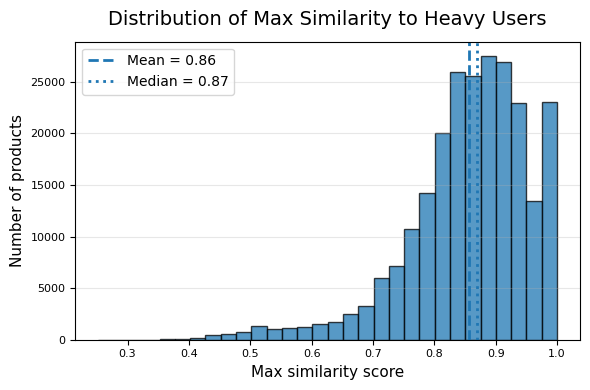

In [50]:
data = one_text_df['max_sim_to_heavy']

plt.figure(figsize=(6, 4))

plt.hist(
    data,
    bins=30,
    alpha=0.75,
    edgecolor='black'
)

mean_val = data.mean()
median_val = data.median()

plt.axvline(mean_val, linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, linestyle=':', linewidth=2, label=f"Median = {median_val:.2f}")

plt.title("Distribution of Max Similarity to Heavy Users", fontsize=14, pad=12)
plt.xlabel("Max similarity score", fontsize=11)
plt.ylabel("Number of products", fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()